# 🎮 Análisis de Tienda Online "Ice"
---
## 📄 Descripción:

En este proyecto, se trabaja para la tienda online "Ice", dedicada a la venta de videojuegos a nivel mundial.

Se dispone de:

* 🧾 fuentes abiertas que contienen reseñas de usuarios y expertos
* 🕹️ géneros
* 💻 plataformas (como Xbox o PlayStation)
* 📊 datos históricos de ventas de juegos

El objetivo es **identificar patrones que determinen el éxito de un juego**, lo cual permitirá:

* 🔍 detectar proyectos prometedores
* 📢 planificar campañas publicitarias
---
## 📅 Contexto de los datos

Se cuenta con datos desde 2016. La planificación se sitúa en diciembre de ese mismo año, con miras a diseñar una campaña para 2017.

El conjunto de datos incluye una columna `"rating"` con la clasificación ESRB de cada juego (por ejemplo, Adolescente o Adulto).
---
## 🔍 Análisis de datos

El análisis de los datos consistirá en:

* examinar cuántos juegos se lanzaron por año y la significatividad de cada período
* observar la variación de ventas entre plataformas, seleccionando las de mayores ventas totales y construyendo distribuciones anuales para identificar plataformas en declive o auge, así como los ciclos de aparición y desaparición
* determinar el período óptimo para construir un modelo orientado a 2017, trabajando solo con datos relevantes
* identificar plataformas líderes, en crecimiento o reducción, y seleccionar las más rentables
* crear diagramas de caja de ventas globales por plataforma para evaluar diferencias significativas y el comportamiento de las ventas promedio
* comparar mediante gráficos de dispersión y correlación cómo afectan las reseñas de usuarios y profesionales a las ventas en una plataforma particular
* comparar ventas del mismo juego entre distintas plataformas
* examinar la distribución por género para identificar los más rentables y generalizar tendencias
---
## 🌍 Perfiles de usuario por región

Posteriormente, se crearán perfiles de usuario para cada región (NA, UE, JP), determinando:

* 🌐 las cinco plataformas principales y las variaciones en sus cuotas de mercado regionales
* 🎮 los cinco géneros principales y sus diferencias
* 🔎 si la clasificación ESRB influye en las ventas de cada región
---
## 🧪 Prueba de hipótesis

Finalmente, las hipótesis a probar serán las siguientes:

1. que las calificaciones promedio de usuarios para Xbox One y PC son iguales
2. que las calificaciones promedio para los géneros Acción y Deportes son diferentes

Para cada una, se explicará:

* la formulación de las hipótesis nula y alternativa
* el criterio estadístico empleado para probarlas (estableciendo un umbral alfa de .05)

## 1. Preprocesamiento de los Datos

In [1]:
# Pirmero, se importan las librerías a utilizar en el resto del proyecto
import pandas as pd
from scipy import stats as st
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns 
import math

In [4]:
# Se importa la base de datos y examina que estén correctamente ordenadas filas y columnas
df = pd.read_csv(r"C:\Users\herna\OneDrive\Desktop\TripleTen\Portafolio_de_Proyectos_Gerardo_Hernandez_Gomez\games.csv")

In [5]:
df

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [6]:
# Como puede advertirse, todo parece estar en orden en relación con el formato del DataFrame, por lo que
# no es necesario añadir parámetros como 'sep=' o 'header=' en la función '.read_csv()'. Ahora bien,
# continuemos con la examinación del contenido de la base de datos; en particular, la potencial aparición
# de valores ausentes en las diferentes variables. 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  str    
 1   Platform         16715 non-null  str    
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  str    
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  str    
 10  Rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 2.0 MB


In [7]:
# Una vez advertimos que tenemos varios valores ausentes en diferentes columnas, es fundamental tomar 
# nota de ello para más adelante tratar la cuestión. Mientras, continuamos con el siguiente paso que marca 
# el ejercicio, a saber: cambiar a minúsculas los nombres de las variables. De esa manera, será más sencillo
# la manipulación de los datos en el resto del análisis.
new_columns = []

for columns in df.columns:
    lowered_columns = columns.lower()
    new_columns.append(lowered_columns)

df.columns = new_columns

print(df.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='str')


In [8]:
# Ahora cabe manejar los valores ausentes. Comenzaré por la columna 'year_of_release', la cual 
# también necesita ser modificada en su tipo de dato, pues ahora mismo es 'float' cuando debería ser 'int'.
# Aquí es importante mencionar que considero más elocuente rellenar las filas NaN con la moda; es decir, el
# valor más repetido en esta variable, ya que se trata del año de lanzamiento de un videojuego. Sustituir por 
# la media o mediana podría ser engañoso y contraproducente en este caso, pues se presta a mayor arbitrareidad.
# Por ejemplo, si usara la media, se podría prestar a un resultado como, por poner un ejemplo, '2007.3', lo cual
# sería absurdo. Por otro lado, aunque la mediana podría arrojar un año válido, no refleja el patrón real 
# de lanzamientos, cosa que sí hace la moda. Esto, al final de cuentas, es una consideración teórica que debe hacerse 
# al momento de elegir la moda, mediana, o el promedio. Es necesario preguntarse realmente cuál tiene más sentido 
# de acuerdo a la naturaleza de los datos manejados.   
print(df['year_of_release'].value_counts(dropna=False))
print(f"La moda es:\n {df['year_of_release'].mode()}")

# Se procederá a llenar con la moda, como ya se mencionó anteriormente.
df['year_of_release'] = df['year_of_release'].fillna(2008)
df['year_of_release'] = df['year_of_release'].astype('int')
print(df)

year_of_release
2008.0    1427
2009.0    1426
2010.0    1255
2007.0    1197
2011.0    1136
2006.0    1006
2005.0     939
2002.0     829
2003.0     775
2004.0     762
2012.0     653
2015.0     606
2014.0     581
2013.0     544
2016.0     502
2001.0     482
1998.0     379
2000.0     350
1999.0     338
1997.0     289
NaN        269
1996.0     263
1995.0     219
1994.0     121
1993.0      62
1981.0      46
1992.0      43
1991.0      41
1982.0      36
1986.0      21
1989.0      17
1983.0      17
1990.0      16
1987.0      16
1988.0      15
1985.0      14
1984.0      14
1980.0       9
Name: count, dtype: int64
La moda es:
 0    2008.0
Name: year_of_release, dtype: float64
                                name platform  year_of_release         genre  \
0                         Wii Sports      Wii             2006        Sports   
1                  Super Mario Bros.      NES             1985      Platform   
2                     Mario Kart Wii      Wii             2008        Racing   
3    

In [9]:
# Se procede ahora con la variable 'critic_score'. En este caso, para poder determinar si es mejor 
# sustituir los valores faltantes con el promedio o mediana cabe hacer dos pruebas concretas. La primera 
# es calcular la diferencias de proporción entre cada una de esas medidas. Lo segundo será realizar un diagrama 
# de caja para visualizar de manera más precisa los valore atípicos que puedan hacer de la mediana una mejor opción
# a considerar. 
media_cs = df['critic_score'].mean()
media_cs = round(media_cs, 1)
print(media_cs)

mediana_cs = df['critic_score'].median()
print(mediana_cs)

# Ahora calculamos las diferencias de proporción entre la media y la mediana 
diferencia_relativa = abs(media_cs - mediana_cs) / mediana_cs * 100
print(f"Diferencia relativa: {diferencia_relativa:.1f}%")
# Como puede observarse, la diferencia de proporción entre la media y la mediana realmente poca, 
# de un 2.8%. Por lo común, para inclinarse por la mediana la diferencia debe estar entre un 10 o 
# 20%. Sin embargo, como prueba definitiva, pasemos a mirar directamente si existen muchos outliers
# con un gráfico de caja. 

69.0
71.0
Diferencia relativa: 2.8%


<Axes: >

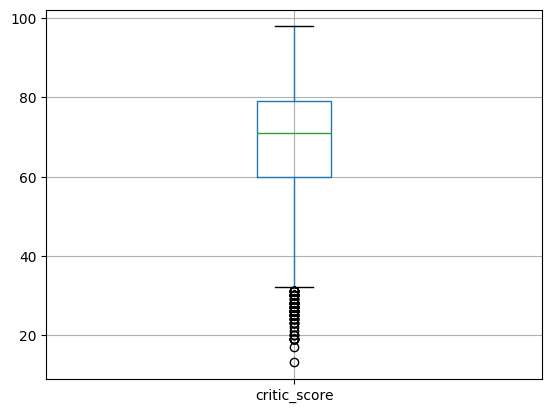

In [10]:
# Aquí podemos apreciar múltiples valores atípicos que pueden estar influyendo nuestro promedio. 
# En consecuencia, vale la pena considerar la mediana para rellenar los valores ausentes en esta columna.
df.boxplot(column='critic_score')

In [11]:
df['critic_score'] = df['critic_score'].fillna(mediana_cs)

In [12]:
# Nos cercioramos de que se hayan sustituido exitosamente los valores. 
df.info()
df['critic_score'].head(50)

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16715 non-null  int64  
 3   genre            16713 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16715 non-null  float64
 9   user_score       10014 non-null  str    
 10  rating           9949 non-null   str    
dtypes: float64(5), int64(1), str(5)
memory usage: 2.0 MB


0     76.0
1     71.0
2     82.0
3     80.0
4     71.0
5     71.0
6     89.0
7     58.0
8     87.0
9     71.0
10    71.0
11    91.0
12    71.0
13    80.0
14    61.0
15    80.0
16    97.0
17    95.0
18    71.0
19    77.0
20    71.0
21    71.0
22    71.0
23    97.0
24    95.0
25    71.0
26    77.0
27    71.0
28    95.0
29    88.0
30    71.0
31    71.0
32    87.0
33    71.0
34    83.0
35    83.0
36    94.0
37    88.0
38    97.0
39    93.0
40    85.0
41    88.0
42    97.0
43    86.0
44    94.0
45    71.0
46    71.0
47    71.0
48    89.0
49    97.0
Name: critic_score, dtype: float64

In [13]:
# Ahora convertimos la columna a tipo 'integer' para adecuarla.
df['critic_score'] = df['critic_score'].astype('int')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16715 non-null  int64  
 3   genre            16713 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16715 non-null  int64  
 9   user_score       10014 non-null  str    
 10  rating           9949 non-null   str    
dtypes: float64(4), int64(2), str(5)
memory usage: 2.0 MB


In [14]:
# Se procede a realizar lo mismo con la columna 'user_score'
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')
print(df['user_score'].unique())


[8.  nan 8.3 8.5 6.6 8.4 8.6 7.7 6.3 7.4 8.2 9.  7.9 8.1 8.7 7.1 3.4 5.3
 4.8 3.2 8.9 6.4 7.8 7.5 2.6 7.2 9.2 7.  7.3 4.3 7.6 5.7 5.  9.1 6.5 8.8
 6.9 9.4 6.8 6.1 6.7 5.4 4.  4.9 4.5 9.3 6.2 4.2 6.  3.7 4.1 5.8 5.6 5.5
 4.4 4.6 5.9 3.9 3.1 2.9 5.2 3.3 4.7 5.1 3.5 2.5 1.9 3.  2.7 2.2 2.  9.5
 2.1 3.6 2.8 1.8 3.8 0.  1.6 9.6 2.4 1.7 1.1 0.3 1.5 0.7 1.2 2.3 0.5 1.3
 0.2 0.6 1.4 0.9 1.  9.7]


In [15]:
media_us = df['user_score'].mean()
media_us = round(media_us, 1)
print(media_us)

mediana_us = df['user_score'].median()
print(mediana_us)

diferencia_relativa_2 = abs(media_us - mediana_us) / mediana_us * 100
print(f"Diferencia relativa: {diferencia_relativa_2:.1f}%")


7.1
7.5
Diferencia relativa: 5.3%


In [16]:
df.boxplot(column='user_score')

<Axes: >

In [17]:

df['user_score'] = df['user_score'].fillna(mediana_us)
df['user_score']
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16715 non-null  int64  
 3   genre            16713 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16715 non-null  int64  
 9   user_score       16715 non-null  float64
 10  rating           9949 non-null   str    
dtypes: float64(5), int64(2), str(4)
memory usage: 2.0 MB


In [18]:
# Procedemos a llenar los valores de 'rating'. Por ser una variable 'string' u 'object', es necesario encontrar la moda, pues con esta 
# podrán sustituirse los NaN en dicha columna. 
print(df['rating'].unique())
print(df['rating'].mode())

moda_rating = df['rating'].mode()

<ArrowStringArray>
['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP']
Length: 9, dtype: str
0    E
Name: rating, dtype: str


In [19]:
# Una vez advertido que la moda es 'E', procedemos a rellenar los valores NaN de la columna 'rating' con esta. 
df['rating'] = df['rating'].fillna('E')
print(df.info())
print(df['rating'])
print(df['rating'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16715 non-null  int64  
 3   genre            16713 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     16715 non-null  int64  
 9   user_score       16715 non-null  float64
 10  rating           16715 non-null  str    
dtypes: float64(5), int64(2), str(4)
memory usage: 2.0 MB
None
0        E
1        E
2        E
3        E
4        E
        ..
16710    E
16711    E
16712    E
16713    E
16714    E
Name: rating, Length: 16715, dtype: str
rating
E       10756
T        2961
M        1563
E10+     1420
EC          8
K-A

In [20]:
# En la columna 'name' sólo hacen falta 2 valores. Basta con sustituirlos con el texto 'unknown'.
df['name'] = df['name'].fillna('unknown')
print(df['name'])
print(df.info())

0                           Wii Sports
1                    Super Mario Bros.
2                       Mario Kart Wii
3                    Wii Sports Resort
4             Pokemon Red/Pokemon Blue
                     ...              
16710    Samurai Warriors: Sanada Maru
16711                 LMA Manager 2007
16712          Haitaka no Psychedelica
16713                 Spirits & Spells
16714              Winning Post 8 2016
Name: name, Length: 16715, dtype: str
<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16715 non-null  int64  
 3   genre            16713 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales     

In [21]:
# Pasa lo mismo con 'genre'. También sustituimos los NaN con el texto 'unknown'.
print(df['genre'].unique())
df['genre'] = df['genre'].fillna('unknown')
print(df['genre'])
print(df.info())

<ArrowStringArray>
[      'Sports',     'Platform',       'Racing', 'Role-Playing',
       'Puzzle',         'Misc',      'Shooter',   'Simulation',
       'Action',     'Fighting',    'Adventure',     'Strategy',
            nan]
Length: 13, dtype: str
0              Sports
1            Platform
2              Racing
3              Sports
4        Role-Playing
             ...     
16710          Action
16711          Sports
16712       Adventure
16713        Platform
16714      Simulation
Name: genre, Length: 16715, dtype: str
<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16715 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16715 non-null  int64  
 3   genre            16715 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64

In [22]:
# Con el uso de la ingeniería de características, creamos una nueva columna para las ventas totales.
df['ventas_totales'] = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']
df

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,ventas_totales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,71,7.5,E,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,71,7.5,E,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,71,7.5,E,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,71,7.5,E,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,71,7.5,E,0.01
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,71,7.5,E,0.01


## 2. Análisis Exploratorio de los Datos
---
Una vez organizado nuestro DataFrame tanto en el formato como en el contenido, se ha cumplimentado con la fase de preprocesamiento de los datos. Nos trasladamos ahora a la siguiente etapa, que es la de análisis descriptivo de los mismos. Esto incluye generar insights incipientas sobre el conjunto de la información a partir de técnicas básicas de estadística y visualización. 

In [23]:
# Comienzo por apreciar la cantidad de juegos lanzados por año. Esto nos puede ayudar a tener una primera impresión de cómo ha crecido y comportado
# el mercado del gaming.
juegos_año_lanzamiento = df[['name', 'year_of_release']]
juegos_año_lanzamiento = juegos_año_lanzamiento.groupby('year_of_release')['name'].count()
juegos_año_lanzamiento = juegos_año_lanzamiento.reset_index()
juegos_año_lanzamiento.rename(columns={'name': 'number_of_games'}, inplace=True)
juegos_año_lanzamiento.sort_values(by='number_of_games', ascending=False)

,year_of_release,number_of_games
28,2008,1696
29,2009,1426
30,2010,1255
27,2007,1197
31,2011,1136
26,2006,1006
25,2005,939
22,2002,829
23,2003,775
24,2004,762


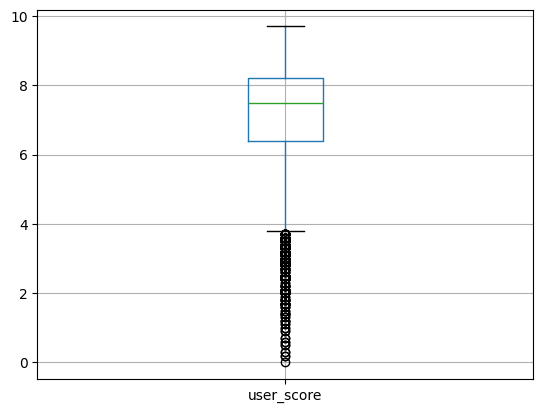

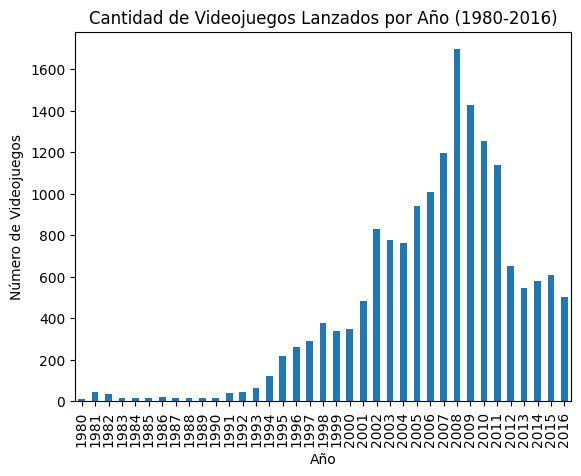

In [24]:
juegos_año_lanzamiento.plot(
        x='year_of_release',
        kind = 'bar',
        title='Cantidad de Videojuegos Lanzados por Año (1980-2016)',
        xlabel='Año',
        ylabel='Número de Videojuegos',
        legend=False)

plt.show()

Aquí es posible apreciar que el año 2008 fue en el que más hubo lanzamientos, siguiéndola una gradual decaída en los subsiguientes. Esto probablemente sugiere que, si bien el mayor fervor por los videojuegos se comprendió desde el año 2001 hasta 2011, permanece un mercado consistente de consumidores que oscila entre los 500 y 700 millones de dólares que puede proyectarse para el año de 2017.

In [25]:
# A continuación realizamos una selección de las top 8 platoformas con más ventas totales y las proyectamos a través del tiempo para apreciar 
# cómo han evolucionado. 

df['platform'].unique()

<ArrowStringArray>
[ 'Wii',  'NES',   'GB',   'DS', 'X360',  'PS3',  'PS2', 'SNES',  'GBA',
  'PS4',  '3DS',  'N64',   'PS',   'XB',   'PC', '2600',  'PSP', 'XOne',
 'WiiU',   'GC',  'GEN',   'DC',  'PSV',  'SAT',  'SCD',   'WS',   'NG',
 'TG16',  '3DO',   'GG', 'PCFX']
Length: 31, dtype: str

In [26]:

top_8_platforms = df.groupby(['platform'])['ventas_totales'].sum().sort_values(ascending=False).head(8).index
top_8_platforms 

Index(['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS', 'GBA', 'PS4'], dtype='str', name='platform')

In [27]:

plat_ventas_totales = df[['platform', 'year_of_release', 'ventas_totales']]
plat_ventas_totales = plat_ventas_totales.groupby(['year_of_release', 'platform'])['ventas_totales'].sum()
plat_ventas_totales = plat_ventas_totales.reset_index()
plat_ventas_totales = plat_ventas_totales[plat_ventas_totales['platform'].isin(top_8_platforms)]
print(plat_ventas_totales)
print(plat_ventas_totales.sort_values(by='ventas_totales', ascending=False))

     year_of_release platform  ventas_totales
8               1985       DS            0.02
47              1994       PS            6.03
55              1995       PS           35.96
64              1996       PS           94.70
70              1997       PS          136.17
..               ...      ...             ...
235             2015     X360           11.96
239             2016      PS3            3.60
240             2016      PS4           69.25
242             2016      Wii            0.18
244             2016     X360            1.52

[81 rows x 3 columns]
     year_of_release platform  ventas_totales
125             2004      PS2          211.81
179             2009      Wii          206.97
113             2002      PS2          205.38
171             2008      Wii          187.65
119             2003      PS2          184.31
..               ...      ...             ...
233             2015      Wii            1.14
191             2011      PS2            0.45
242        

In [28]:
plt.figure(figsize=(15,5))
sns.lineplot(
    data=plat_ventas_totales,
    x='year_of_release',
    y='ventas_totales',
    hue='platform',
    marker='o'
)

plt.title('Ventas Totales por Año de las Top 8 Mejores Plataformas de Videojuegos (1993-2016)')
plt.xlim([1993, 2017])
plt.xlabel('Año')
plt.ylabel('Ventas Totales en Millones de Dólares')

Text(0, 0.5, 'Ventas Totales en Millones de Dólares')

En esta gráfica, podemos apreciar diversas cuestiones. En primer lugar, se exponen los ciclos de vida de las múltiples plataformas de videojuegos, en donde hay las que fueron longevas como 'PS' y otras que desaparecieron en un relativamente corto lapso de tiempo, como es el caso de 'GBA'. Aquí únicamente hay que hacer un comentario sobre la plataforma 'PS4', puesto que se puede tener la falsa impresión de que tuvo el plazo más corto de todos, pero recuérdese que los datos registrados únicamente llegan hasta 2016. Esto es, aún falta esperar para poder apreciar el comportamiento completo de esta plataforma. Sin embargo, de lo que es posible intuir a partir del comportamiento que muestra, es que ya va en franca picada a pesar del periodo tan corto que lleva, lo cual hace muy probable que continue así para los próximos años, incluyendo el 2017. 
En segundo lugar, la gráfica permite apreciar los máximos en ventas de cada plataforma, en donde la 'PS2' aparece como aquella que más ha recaudado ingresos de todas las demás, en especial en los dos picos de los años 2002 y 2004 en donde recaudó alrededor de 205 y 211 millones de dólares respectivamente. Después le seguiría 'Wii', la cual en el año 2009 logró alcanzar los 206 millones de dólares. 

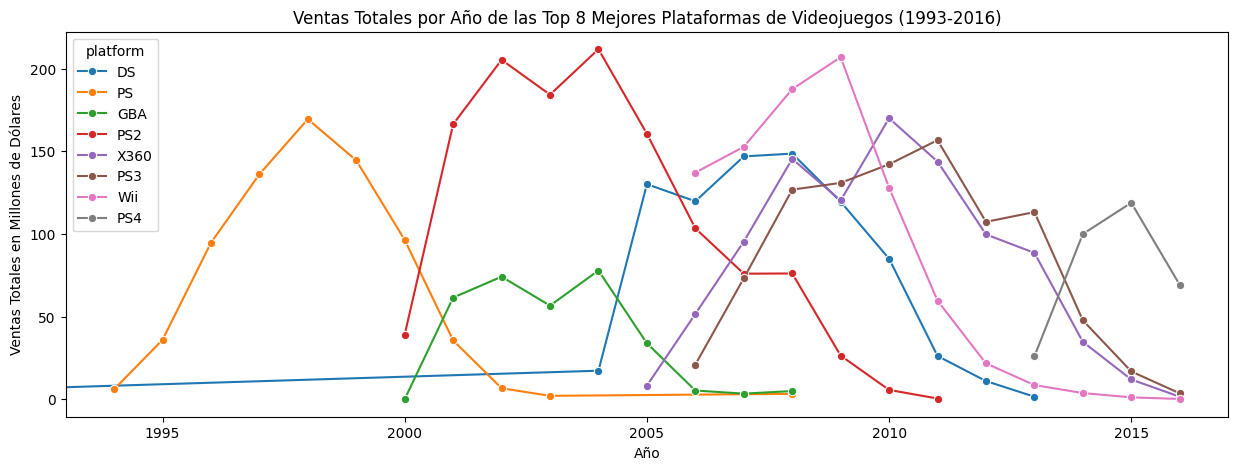

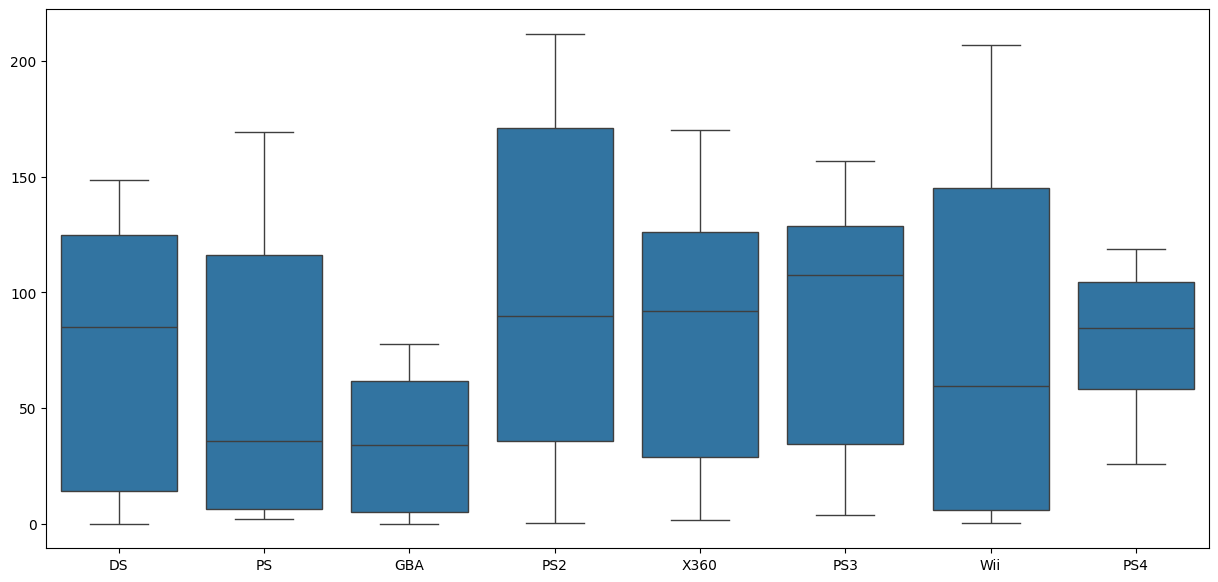

In [29]:
plt.figure(figsize=(15, 7))
sns.boxplot(data=plat_ventas_totales, 
            x='platform',
            y='ventas_totales',
           )
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.show()

Con este gráfico de caja nos refuerza la información anterior. Tan sólo el primer cuartil de 'PS2' es mayor que la media de 'PS' y 'GBA', mientras que su tercer cuartil está muy por encima que el resto de plataformas. 

In [30]:
# Sin embargo, todavía falta filtrar por un periodo de tiempo significativo para hacer estimaciones en torno
# al año 2017.  
pvt_2010_2016 = plat_ventas_totales[plat_ventas_totales['year_of_release'].isin([2010, 2011, 2012, 2013, 2014, 2015, 2016])]
pvt_2010_2016

,year_of_release,platform,ventas_totales
181,2010,DS,85.02
183,2010,PS2,5.64
184,2010,PS3,142.17
186,2010,Wii,127.95
187,2010,X360,170.03
189,2011,DS,26.18
191,2011,PS2,0.45
192,2011,PS3,156.78
195,2011,Wii,59.65
196,2011,X360,143.84


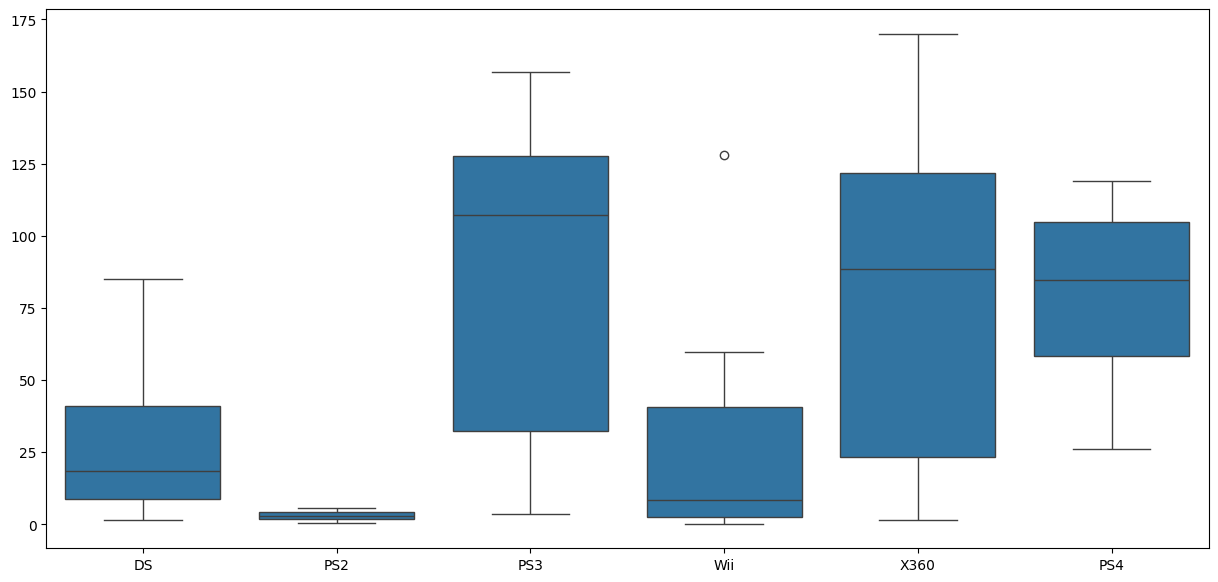

In [31]:
plt.figure(figsize=(15, 7))
sns.boxplot(data=pvt_2010_2016, 
            x='platform',
            y='ventas_totales',
           )
plt.title('')
plt.xlabel('')
plt.ylabel('')
plt.show()

In [32]:
# Ahora vamos a corroborar si los puntajes de los usuarios están correlacionados con las ventas totales 
# de cada videojuego. La plataforma que elijo para hacer este ejercicio es PS2, ya que es la que tuvo 
# mayor número de ventas totales y sería interesante saber si acaso este éxito se debe en parte a la calificación de los consumidores. 
plat_corr = df[df['platform'] == 'PS2']
plat_corr

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,ventas_totales
17,Grand Theft Auto: San Andreas,PS2,2004,Action,9.43,0.40,0.41,10.57,95,9.0,M,20.81
24,Grand Theft Auto: Vice City,PS2,2002,Action,8.41,5.49,0.47,1.78,95,8.7,M,16.15
28,Gran Turismo 3: A-Spec,PS2,2001,Racing,6.85,5.09,1.87,1.16,95,8.4,E,14.97
38,Grand Theft Auto III,PS2,2001,Action,6.99,4.51,0.30,1.30,97,8.5,M,13.10
48,Gran Turismo 4,PS2,2004,Racing,3.01,0.01,1.10,7.53,89,8.5,E,11.65
...,...,...,...,...,...,...,...,...,...,...,...,...
16670,Sugar + Spice! Anoko no Suteki na Nanimokamo,PS2,2008,Adventure,0.00,0.00,0.01,0.00,71,7.5,E,0.01
16671,Kanokon: Esuii,PS2,2008,Adventure,0.00,0.00,0.01,0.00,71,7.5,E,0.01
16683,Scarlett: Nichijou no Kyoukaisen,PS2,2008,Adventure,0.00,0.00,0.01,0.00,71,7.5,E,0.01
16689,Real Rode,PS2,2008,Adventure,0.00,0.00,0.01,0.00,71,7.5,E,0.01


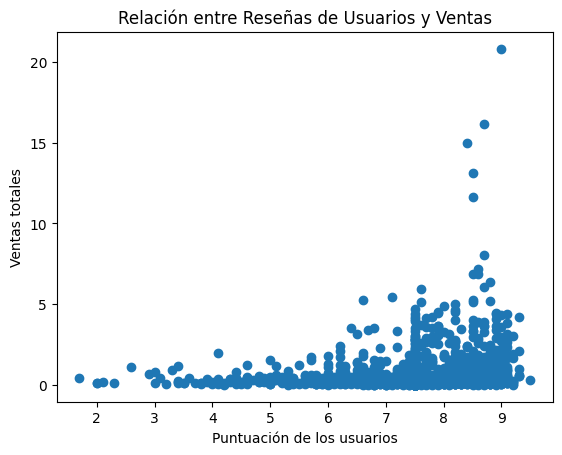

In [33]:
# Se realiza un gráfico de dispersión, en donde en el eje de la 'x' ponemos la variable independiente, 
# mientras que en el de la 'y' la independiente. Aquí están los principios de la regresión lineal.
# Primero, hagamos el intento con 'user_score' y luego con 'critic_score', para observar las diferencias

# Con 'user_score':
plt.scatter(plat_corr['user_score'], plat_corr['ventas_totales'])
plt.xlabel('Puntuación de los usuarios')
plt.ylabel('Ventas totales')
plt.title('Relación entre Reseñas de Usuarios y Ventas')
plt.show()


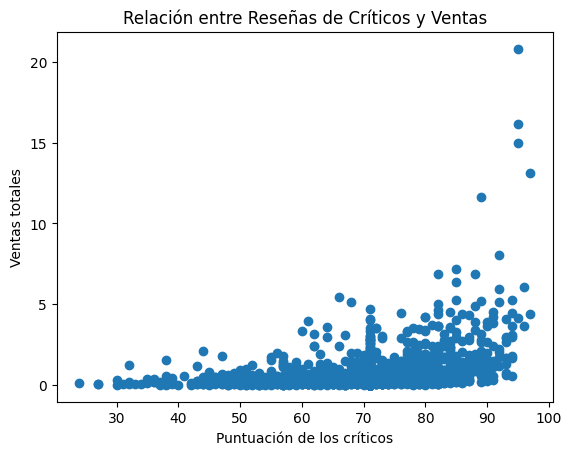

In [34]:
plt.scatter(plat_corr['critic_score'], plat_corr['ventas_totales'])
plt.xlabel('Puntuación de los críticos')
plt.ylabel('Ventas totales')
plt.title('Relación entre Reseñas de Críticos y Ventas')
plt.show()

In [35]:
# Vemos que la correlación tiene un coeficiente de 0.17, lo cual indica su débil carácter. Por lo tanto, los puntajes de los consumidores parecen
# no jugar un papel relevante en las ventas. 
corr = plat_corr['user_score'].corr(plat_corr['ventas_totales'])
print(f"Correlación entre 'user_score' y 'ventas_totales': {corr}")

corr_2 = plat_corr['critic_score'].corr(plat_corr['ventas_totales'])
print(f"Correlación entre 'critic_score' y 'ventas_totales': {corr_2}")


Correlación entre 'user_score' y 'ventas_totales': 0.1748565837500128
Correlación entre 'critic_score' y 'ventas_totales': 0.3454765724600362


In [36]:
# Proseguimos con el género, analizar cuáles son los que más han generado ingresos totales.
gen_ventas = df[['genre', 'ventas_totales']]
gen_ventas = gen_ventas.groupby('genre')['ventas_totales'].sum()
gen_ventas = gen_ventas.reset_index()

gen_ventas.sort_values(by='ventas_totales', ascending=False)

,genre,ventas_totales
0,Action,1744.17
10,Sports,1331.27
8,Shooter,1052.45
7,Role-Playing,934.56
4,Platform,827.77
3,Misc,802.51
6,Racing,728.67
2,Fighting,447.53
9,Simulation,389.97
5,Puzzle,242.57


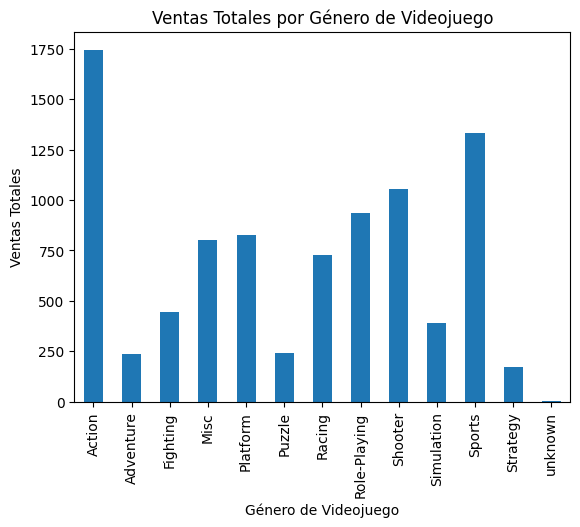

In [37]:
gen_ventas.plot(
        x='genre',
        y='ventas_totales',
        kind = 'bar',
        title='Ventas Totales por Género de Videojuego',
        xlabel='Género de Videojuego',
        ylabel='Ventas Totales',
        legend=False)

plt.show()

Tenemos que, en total, el género de acción ha recaudado más ventas, con una diferencia bastante considerable respecto a los demás generos, lo cual lo hace uno sumamente rentable. Los siguientes serían los de deportes y 'shooters' correspondientemente. No obstante, aquí hace falta una consideración temporal, sobre cómo han variado las ventas de cada género a lo largo de los años.

In [38]:
# Se realiza, de acuerdo con el comentario anterior, un desglose de las ventas totales por género a lo largo del tiempo.  
gen_ventas_tiempo = df[['year_of_release', 'genre', 'ventas_totales']]
gen_ventas_tiempo = gen_ventas_tiempo.groupby(['year_of_release', 'genre'])['ventas_totales'].sum()
gen_ventas_tiempo = gen_ventas_tiempo.reset_index()
print(gen_ventas_tiempo)
print(gen_ventas_tiempo.sort_values(by='ventas_totales', ascending=False))

     year_of_release         genre  ventas_totales
0               1980        Action            0.34
1               1980      Fighting            0.77
2               1980          Misc            2.70
3               1980       Shooter            7.07
4               1980        Sports            0.50
..               ...           ...             ...
383             2016  Role-Playing           18.18
384             2016       Shooter           38.22
385             2016    Simulation            1.89
386             2016        Sports           23.49
387             2016      Strategy            1.13

[388 rows x 3 columns]
     year_of_release       genre  ventas_totales
280             2008      Action          162.61
292             2009      Action          137.69
302             2009      Sports          137.37
266             2006      Sports          135.78
340             2013      Action          122.51
..               ...         ...             ...
78              1991 

In [39]:
plt.figure(figsize=(15,10))
sns.lineplot(
    data=gen_ventas_tiempo,
    x='year_of_release',
    y='ventas_totales',
    hue='genre',
    marker='o'
)

plt.title('Ventas Totales por Año y Género de Videojuego (2000-2016)')
plt.xlim([2000, 2017])
plt.xlabel('Año')
plt.ylabel('Ventas en Millones de Dólares')

Text(0, 0.5, 'Ventas en Millones de Dólares')

Aquí podemos observar que, todos los géneros en realidad van a la baja en sus ventas, en un ritmo que en realidad coincide con la anterior gráfica de la cantidad de videojuegos lanzados por año. Responde a una tendencia decreciente general que, no obstante, conserva un mercado para el año 2017. Lo mejor para las plataformas en el 2017 será centrarse en los juegos de acción, shooters, sports y role-playing. 

In [40]:
# Queda particularizar en las ventas por plataforma en cada una de las regiones individualmente, para así poder determinar las particularidades
# de cada mercado. 

# Ventas por plataforma en Norteamérica
na_platforms = df.groupby('platform')['na_sales'].sum().sort_values(ascending=False)
top5_na = na_platforms.head(5)

print(na_platforms)
print(top5_na)

platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
PS      336.52
GBA     187.54
XB      186.69
N64     139.02
GC      133.46
NES     125.94
GB      114.32
PSP     109.17
PS4     108.74
PC       94.53
XOne     93.12
2600     90.60
3DS      83.49
SNES     61.23
WiiU     38.10
GEN      21.05
PSV      12.58
DC        5.43
SCD       1.00
SAT       0.72
GG        0.00
3DO       0.00
PCFX      0.00
NG        0.00
WS        0.00
TG16      0.00
Name: na_sales, dtype: float64
platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64


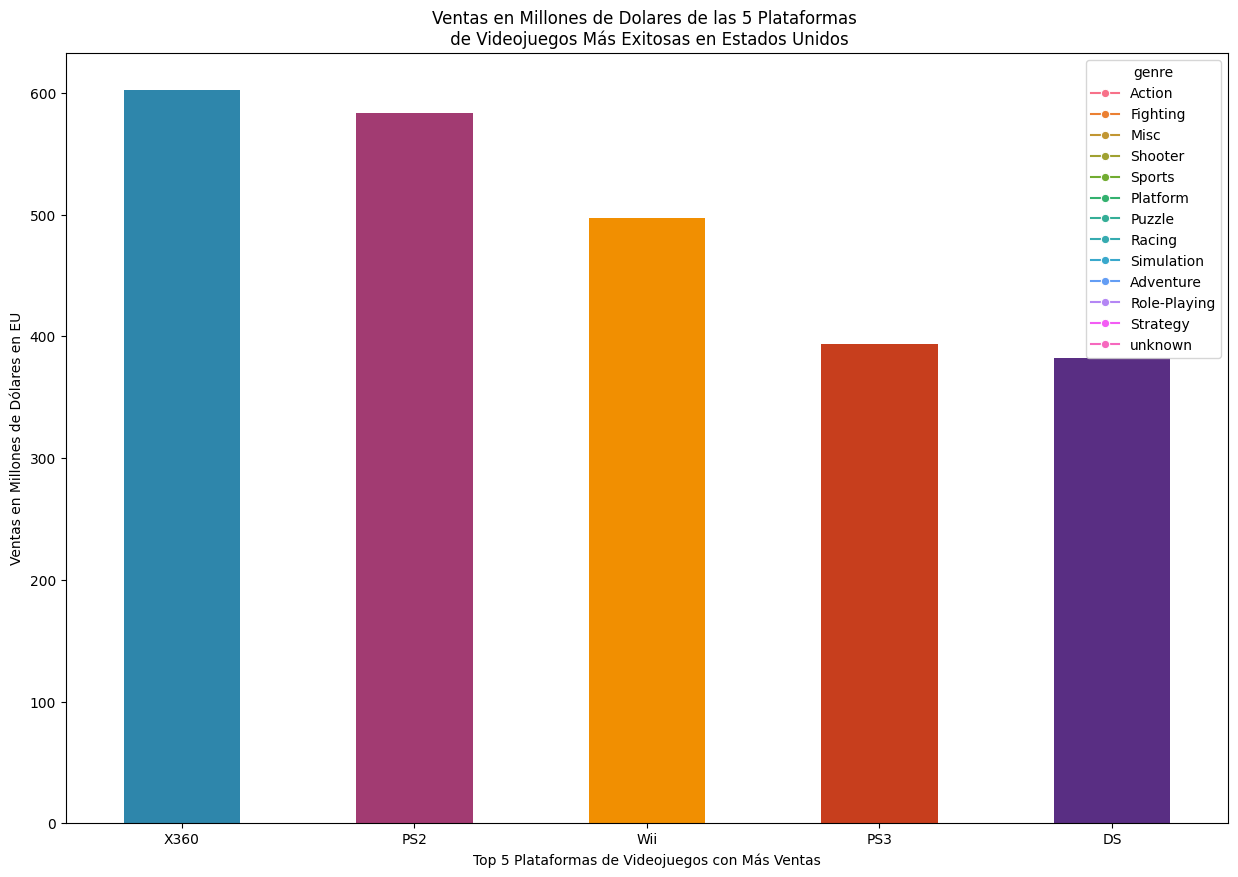

In [41]:
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#592E83']

top5_na.plot(
    kind='bar',
    xlabel='Top 5 Plataformas de Videojuegos con Más Ventas',
    ylabel='Ventas en Millones de Dólares en EU',
    rot=360,
    legend=False,
    title='Ventas en Millones de Dolares de las 5 Plataformas \n de Videojuegos Más Exitosas en Estados Unidos',
    color=colors
)

plt.show()

En Estados Unidos, es posible observar que la plataforma 'X360' es la que genera más ventas, siguiéndole la 'PS2' y el 'Wii'.

In [42]:
# Ventas por plataforma en Europa  
eu_platforms = df.groupby('platform')['eu_sales'].sum().sort_values(ascending=False)
top5_eu = eu_platforms.head(5)
print(eu_platforms)
print(top5_eu)

platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
DS      188.89
PC      142.44
PS4     141.09
GBA      75.25
PSP      66.68
3DS      61.48
XB       60.95
XOne     51.59
GB       47.82
N64      41.06
GC       38.71
WiiU     25.13
NES      21.15
SNES     19.04
PSV      13.12
GEN       6.05
2600      5.47
DC        1.69
SAT       0.54
SCD       0.36
GG        0.00
3DO       0.00
PCFX      0.00
NG        0.00
WS        0.00
TG16      0.00
Name: eu_sales, dtype: float64
platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
Name: eu_sales, dtype: float64


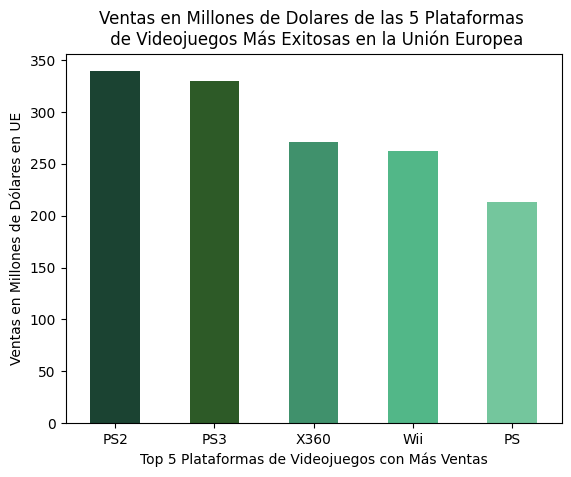

In [43]:

colors = ['#1B4332', '#2D5A27', '#40916C', '#52B788', '#74C69D']

top5_eu.plot(
    kind='bar',
    xlabel='Top 5 Plataformas de Videojuegos con Más Ventas',
    ylabel='Ventas en Millones de Dólares en UE',
    rot=360,
    legend=False,
    title='Ventas en Millones de Dolares de las 5 Plataformas \n de Videojuegos Más Exitosas en la Unión Europea',
    color=colors
)

plt.show()

En la Unión Europea, es posible observar que la plataforma 'PS2' es la que genera más ventas, siguiéndole la 'PS3' y el 'X360'.

In [44]:
# Ventas por plataforma en Japón
jp_platforms = df.groupby('platform')['jp_sales'].sum().sort_values(ascending=False)
top5_jp = jp_platforms.head(5)
print(jp_platforms)
print(top5_jp)

platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
NES      98.65
GB       85.12
PS3      80.19
PSP      76.78
Wii      69.33
GBA      47.33
N64      34.22
SAT      32.26
PSV      21.91
GC       21.58
PS4      15.96
WiiU     13.01
X360     12.43
DC        8.56
GEN       2.70
NG        1.44
WS        1.42
XB        1.38
SCD       0.45
XOne      0.34
PC        0.17
TG16      0.16
3DO       0.10
GG        0.04
PCFX      0.03
2600      0.00
Name: jp_sales, dtype: float64
platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
Name: jp_sales, dtype: float64


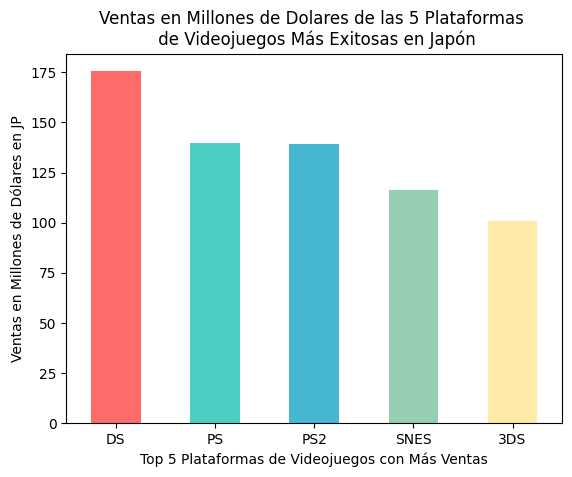

In [45]:

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

top5_jp.plot(
    kind='bar',
    xlabel='Top 5 Plataformas de Videojuegos con Más Ventas',
    ylabel='Ventas en Millones de Dólares en JP',
    rot=360,
    legend=False,
    title='Ventas en Millones de Dolares de las 5 Plataformas \n de Videojuegos Más Exitosas en Japón',
    color=colors
)

plt.show()

En Japón, es posible observar que la plataforma 'DS' es la que genera más ventas, siguiéndole la 'PS' y el 'PS2'.

In [46]:
# A continuación, huelga describir las variaciones de una región a otra en lo que concierne a sus cuotas de mercado por plataforma. 
# En este contexto, estoy interpretando las cuotas de mercado como el porcentaje de participación de cada plataforma en las ventas 
# de una región particular. 

# Calcular el total de ventas en NA, EU y JP

# Total de ventas NA
total_na_sales = df['na_sales'].sum()
print(f"El total de ventas en Estados Unidos equivale a: {total_na_sales}")

# Total de ventas EU
total_eu_sales = df['eu_sales'].sum()
print(f"El total de ventas en la Unión Europea equivale a: {total_eu_sales}")

# Total de ventas JP
total_jp_sales = df['jp_sales'].sum()
print(f"El total de ventas en Japón equivale a: {total_jp_sales}")

# Calcular cuotas de mercado (porcentajes) por cada región

# Cuota de mercado en NA 
print(f"Top 5 plataformas con más ventas en Estados Unidos:\n{top5_na}")
top5_na_market_share = (top5_na / total_na_sales) * 100
print(f"Cuota de mercado de las top 5 plataformas con más ventas en Estados Unidos:\n{top5_na_market_share}")


# Cuota de mercado en EU
print(f"Top 5 plataformas con más ventas en la Unión Europea:\n{top5_eu}")
top5_eu_market_share = (top5_eu / total_eu_sales) * 100
print(f"Cuota de mercado de las top 5 plataformas con más ventas en la Unión Europea:\n{top5_eu_market_share}")

# Cuota de mercado en JP
print(f"Top 5 plataformas con más ventas en Japón:\n{top5_jp}")
top5_jp_market_share = (top5_jp / total_jp_sales) * 100
print(f"Cuota de mercado de las top 5 plataformas con más ventas en Japón:\n{top5_jp_market_share}")


El total de ventas en Estados Unidos equivale a: 4402.349999999999
El total de ventas en la Unión Europea equivale a: 2424.67
El total de ventas en Japón equivale a: 1297.37
Top 5 plataformas con más ventas en Estados Unidos:
platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64
Cuota de mercado de las top 5 plataformas con más ventas en Estados Unidos:
platform
X360    13.685191
PS2     13.262008
Wii     11.287153
PS3      8.938181
DS       8.686270
Name: na_sales, dtype: float64
Top 5 plataformas con más ventas en la Unión Europea:
platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
Name: eu_sales, dtype: float64
Cuota de mercado de las top 5 plataformas con más ventas en la Unión Europea:
platform
PS2     13.993244
PS3     13.622060
X360    11.166880
Wii     10.814255
PS       8.809859
Name: eu_sales, dtype: float64
Top 5 plataformas con más ventas en Japón:
platform
DS      175.57
PS      1

Lo primero que cabría decir de estas cifras es que el mercado de Estados Unidos es muy similar al de la Unión Europea en términos de las top 5 plataformas que generan más ingresos en sus respectivas regiones, pero también en lo que se refiere al porcentaje de participación o cuota de mercado de cada una de ellas. Las plataformas que priman en ambas regiones son el 'PS2', 'X360', 'Wii', y 'PS3'. Esto difiere bastante del mercado japonés, en donde tan sólo el 'PS2' aparece dentro de su top 5 (en tercer lugar para ser específicos). Aquí, más bien, las plataformas 'DS', 'PS', 'PS2' y 'SNES' tienen mayor peso, por lo que, dependiendo de la región, habrá que invertir mayor o menor cantidad de dinero en ciertas plataformas, la publicidad de sus juegos exclusivos, la cantidad de copias de estos últimos, etc. 

In [47]:
# En esta parte, realizamos un breve ejercicio que descripa las ventas de cada género de videojuego según la región, con el propósito de 
# averiguar qué generos son más exitosos en determinadas regiones. 
top5_genres_na = df.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)
top5_genres_na

genre
Action      879.01
Sports      684.43
Shooter     592.24
Platform    445.50
Misc        407.27
Name: na_sales, dtype: float64

In [48]:
top5_genres_eu = df.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
top5_genres_eu

genre
Action     519.13
Sports     376.79
Shooter    317.34
Racing     236.51
Misc       212.74
Name: eu_sales, dtype: float64

In [49]:
top5_genres_jp = df.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)
top5_genres_jp

genre
Role-Playing    355.41
Action          161.43
Sports          135.54
Platform        130.83
Misc            108.11
Name: jp_sales, dtype: float64

Aquí puede reforzarse lo anteriormente dicho: los mercados de Estados Unidos y la Unión Europea son sumamente similares, con lo que puede incluso aseverarse que las ventas de títulos en una plataforma u otra serán bastante similares en ambas regiones. En estos mercados, vale la pena centrarse en la producción de juegos de acción, 'shooters' y de deportes. Por otro lado, en Japón, la estrategia tiene que orientarse a videojuegos de 'role-playing', acción y deportes. Finalmente, sólo en Estados Unidos y Japón vale la pena desarrollar videojuegos cuyo género sea 'platform'.

In [50]:
# Ahora bien, sigue apreciar si las clasificaciones de ESRB afectan a las ventas en regiones individuales. Podrá 
# pensarse a primera cuenta que para ello será necesario hacer gráficos de dispersión y correlaciones. Sin embargo,
# las variables en este caso no se prestan para ello por su misma naturaleza, ya que la columna 'rating' es string, 
# y no es posible hacer una correlación entre una variable de este tipo con una cuantitativa respectivamente. Por lo tanto
# resolveremos esta cuestión a partir de los gráficos de barras, los cuales nos permitirán visualizar las ventas en cada región
# según las categorías de clasificación y analizar si estas últimas tienen un impacto en aquellas. 

# Estados Unidos:
rating_na_sales = df.groupby('rating')['na_sales'].sum()
rating_na_sales = rating_na_sales.sort_values(ascending=False)
rating_na_sales

rating
E       2535.45
T        759.75
M        748.48
E10+     353.32
K-A        2.56
EC         1.53
AO         1.26
RP         0.00
Name: na_sales, dtype: float64

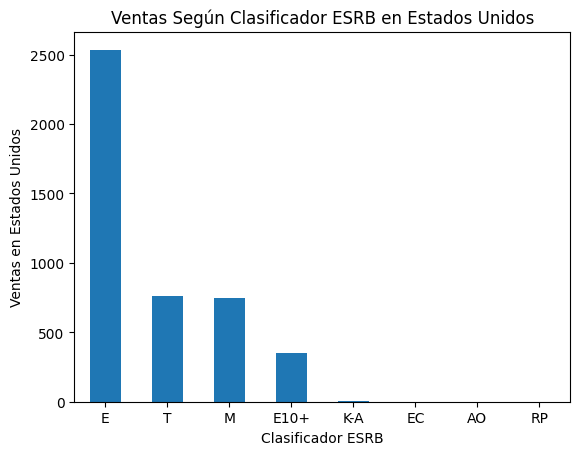

In [51]:

rating_na_sales.plot(
    kind='bar',
    xlabel='Clasificador ESRB',
    ylabel='Ventas en Estados Unidos',
    rot=360,
    legend=False,
    title='Ventas Según Clasificador ESRB en Estados Unidos',
)

plt.show()

In [52]:
# Unión Europea 
rating_eu_sales = df.groupby('rating')['eu_sales'].sum()
rating_eu_sales = rating_eu_sales.sort_values(ascending=False)
rating_eu_sales

rating
E       1324.08
M        483.97
T        427.03
E10+     188.52
AO         0.61
K-A        0.27
EC         0.11
RP         0.08
Name: eu_sales, dtype: float64

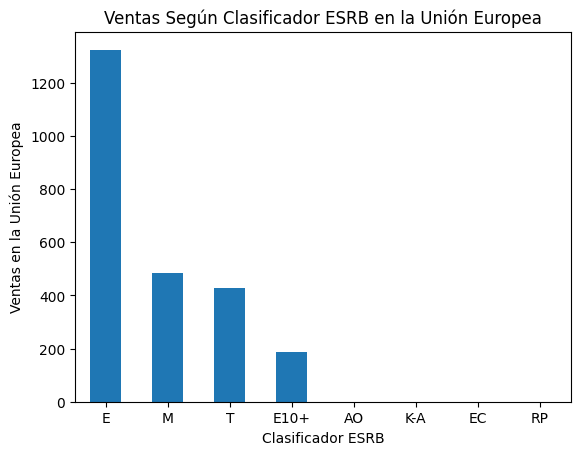

In [53]:

rating_eu_sales.plot(
    kind='bar',
    xlabel='Clasificador ESRB',
    ylabel='Ventas en la Unión Europea',
    rot=360,
    legend=False,
    title='Ventas Según Clasificador ESRB en la Unión Europea',
)

plt.show()

In [54]:
# Japón 
rating_jp_sales = df.groupby('rating')['jp_sales'].sum()
rating_jp_sales = rating_jp_sales.sort_values(ascending=False)
rating_jp_sales

rating
E       1040.07
T        151.40
M         64.24
E10+      40.20
K-A        1.46
AO         0.00
EC         0.00
RP         0.00
Name: jp_sales, dtype: float64

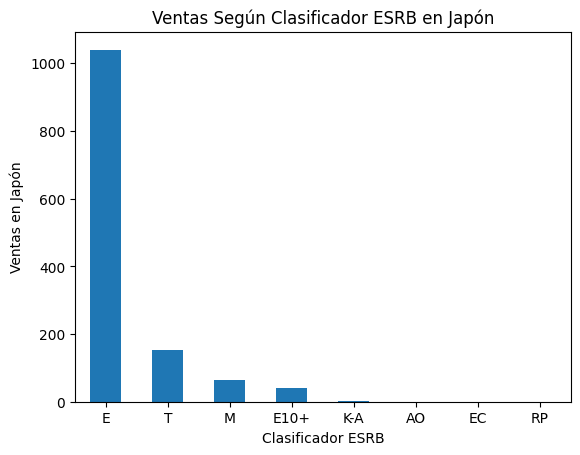

In [55]:


rating_jp_sales.plot(
    kind='bar',
    xlabel='Clasificador ESRB',
    ylabel='Ventas en Japón',
    rot=360,
    legend=False,
    title='Ventas Según Clasificador ESRB en Japón',
)

plt.show()

A partir de estas gráficas, es posible sostener que la clasificación 'E', en los tres países, tiene una clara ventaja en ventas en las tres regiones, por lo que es una buena estrategia centrarse de manera generalizada en la producción de videojuegos cuyo contenido entra dentro de dicha categoría. 

## 3. Pruebas de Hipótesis

In [56]:
# Primero, cabe filtrar un DataFrame que sólo sea de las plataformas 'XOne' y 'PC'.

# DataFrame 'XOne'
xbox_one = df[df['platform'].isin(['XOne'])]
print(xbox_one)
xbox_one = xbox_one['user_score']
print(xbox_one)

                                                name platform  \
99                         Call of Duty: Black Ops 3     XOne   
165                               Grand Theft Auto V     XOne   
179                   Call of Duty: Advanced Warfare     XOne   
242                                Halo 5: Guardians     XOne   
270                                        Fallout 4     XOne   
...                                              ...      ...   
16630                       Sébastien Loeb Rally Evo     XOne   
16643                              Rugby Challenge 3     XOne   
16645                                         ZombiU     XOne   
16660                               Prison Architect     XOne   
16672  Metal Gear Solid V: The Definitive Experience     XOne   

       year_of_release         genre  na_sales  eu_sales  jp_sales  \
99                2015       Shooter      4.59      2.11      0.01   
165               2014        Action      2.81      2.19      0.00   
179      

In [57]:
# DataFrame 'PC'
pc = df[df['platform'].isin(['PC'])]
print(pc)
pc = pc['user_score']
print(pc)

                                    name platform  year_of_release  \
85                            The Sims 3       PC             2009   
138                    World of Warcraft       PC             2004   
192                           Diablo III       PC             2012   
195           Microsoft Flight Simulator       PC             1996   
218       StarCraft II: Wings of Liberty       PC             2010   
...                                  ...      ...              ...   
16690                     Pony Friends 2       PC             2009   
16692  Metal Gear Solid V: Ground Zeroes       PC             2014   
16696                             Breach       PC             2011   
16702            STORM: Frontline Nation       PC             2011   
16705                            15 Days       PC             2009   

              genre  na_sales  eu_sales  jp_sales  other_sales  critic_score  \
85       Simulation      0.99      6.42       0.0         0.60            86   

In [58]:
# Aquí, la hipótesis nula plantea que las calificaciones promedio de los 
# usuarios para las plataformas Xbox One y PC son las mismas, mientras que
# la alternativa lo contrario, esto es, que son diferentes. 
alpha = .05

prueba_hipotesis_1 = st.ttest_ind(xbox_one, pc, equal_var=False)

print('valor p:', prueba_hipotesis_1.pvalue)

if prueba_hipotesis_1.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

valor p: 4.964162612622159e-05
Rechazamos la hipótesis nula



La prueba marca que rechazemos la hipótesis nula, por lo que podemos afirmar que las calificaciones promedio de los 
usuarios para las plataformas Xbox One y PC son diferentes. 


In [59]:
df['genre'].unique()

action = df[df['genre'].isin(['Action'])]
print(action)

action = action['user_score']
print(action)

                                    name platform  year_of_release   genre  \
16                    Grand Theft Auto V      PS3             2013  Action   
17         Grand Theft Auto: San Andreas      PS2             2004  Action   
23                    Grand Theft Auto V     X360             2013  Action   
24           Grand Theft Auto: Vice City      PS2             2002  Action   
38                  Grand Theft Auto III      PS2             2001  Action   
...                                  ...      ...              ...     ...   
16692  Metal Gear Solid V: Ground Zeroes       PC             2014  Action   
16694                     Carmageddon 64      N64             1999  Action   
16695                    Planet Monsters      GBA             2001  Action   
16699              The Longest 5 Minutes      PSV             2016  Action   
16710      Samurai Warriors: Sanada Maru      PS3             2016  Action   

       na_sales  eu_sales  jp_sales  other_sales  critic_score 

In [60]:
sports = df[df['genre'].isin(['Sports'])]
print(sports)

sports = sports['user_score']
print(sports)

                                name platform  year_of_release   genre  \
0                         Wii Sports      Wii             2006  Sports   
3                  Wii Sports Resort      Wii             2009  Sports   
13                           Wii Fit      Wii             2007  Sports   
15                      Wii Fit Plus      Wii             2009  Sports   
77                           FIFA 16      PS4             2015  Sports   
...                              ...      ...              ...     ...   
16676               G1 Jockey 4 2008      PS3             2008  Sports   
16688  Outdoors Unleashed: Africa 3D      3DS             2011  Sports   
16693              PGA European Tour      N64             2000  Sports   
16700       Mezase!! Tsuri Master DS       DS             2009  Sports   
16711               LMA Manager 2007     X360             2006  Sports   

       na_sales  eu_sales  jp_sales  other_sales  critic_score  user_score  \
0         41.36     28.96      3.

In [61]:
# Por otro lado, aquí, la hipótesis nula afirma que las calificaciones promedio de los usuarios 
# para los géneros de Acción y Deportes son iguales, mientras que la hipótesis alternativa afirma 
# que son diferentes. 
alpha = .05

prueba_hipotesis_2 = st.ttest_ind(action, sports, equal_var=False)

print('valor p:', prueba_hipotesis_2.pvalue)

if prueba_hipotesis_2.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

valor p: 0.7159128316394158
No podemos rechazar la hipótesis nula


La prueba marca que no podemos rechazar la hipótesis nula, por lo que podemos afirmar que las calificaciones promedio de los usuarios 
para los géneros de Acción y Deportes son iguales


# Conclusiones
---
Hay varios puntos que mencionar en torno a las estrategias de venta para 2017. Basándonos en los datos históricos, es recomendable, en primer
lugar que los juegos de 'PS2' y 'Wii' especialmente (y en menor medida 'PS') se remastericen o hagan 'remakes' adaptados a las nuevas plataformas como 'PS3', debido al rotundo éxito en ventas que tuvieron en su momento, sobre todo en Estados Unidos y Europa. Esto, de hecho, podría reponer la caída que está atravesando la 'PS3', a pesar de su corto periodo de tiempo en el mercado. Ahora bien, dependiendo de las regiones, vale la pena invertir más en ciertas plataformas que en otras. Por ejemplo, tanto en Estados Unidos como en Europa pueden crearse eventos exclusivos de 'X360', además de armar un mayor inventario de consolas y videojuegos de esa plataforma, promociones específicas, ediciones especiales, etc. En cambio, en Japón quizás vale más la pena hacer lo anterior, pero en torno a la plataforma 'DS' o 'Nintendo' en general. El 'PS2' o la serie 'PlayStation' es éxitosa en las tres regiones, por lo que puede dedicársele a esta una estrategia más global. Por otro lado, en Japón deberá centrarse la producción en videojuegos cuyo género sea de 'role-playing', lo cual puede desantenderse un poco más en Estados Unidos y Europa, ya que no existe una gran demanda por ellos. En cambio, géneros éxitosos comunes son especialmente 'Action', 'Shooters', 'Misc' y 'Platform', por lo que el mercado internacional responde generalmente bien a los videojuegos de estos tipos. Ahora bien, por último, lo más conveniente es que haya un esfuerzo mayor en producir los videojuegos con todas estas características mencionadas, pero que, adicionalmente, la mayoría se ajuste a los criterios de la clasificación ESRB 'E', debido a que esta es la que, con creces, ha generado más ventas entre las demás. 